<a href="https://colab.research.google.com/github/Bravinkindi9/jolmi-research/blob/main/jolmi_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 120.7 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: geemap
    Found existing installation: geemap 0.38.3
    Uninstalling geemap-0.38.3:
      Successfully uninstalled geemap-0.38.3


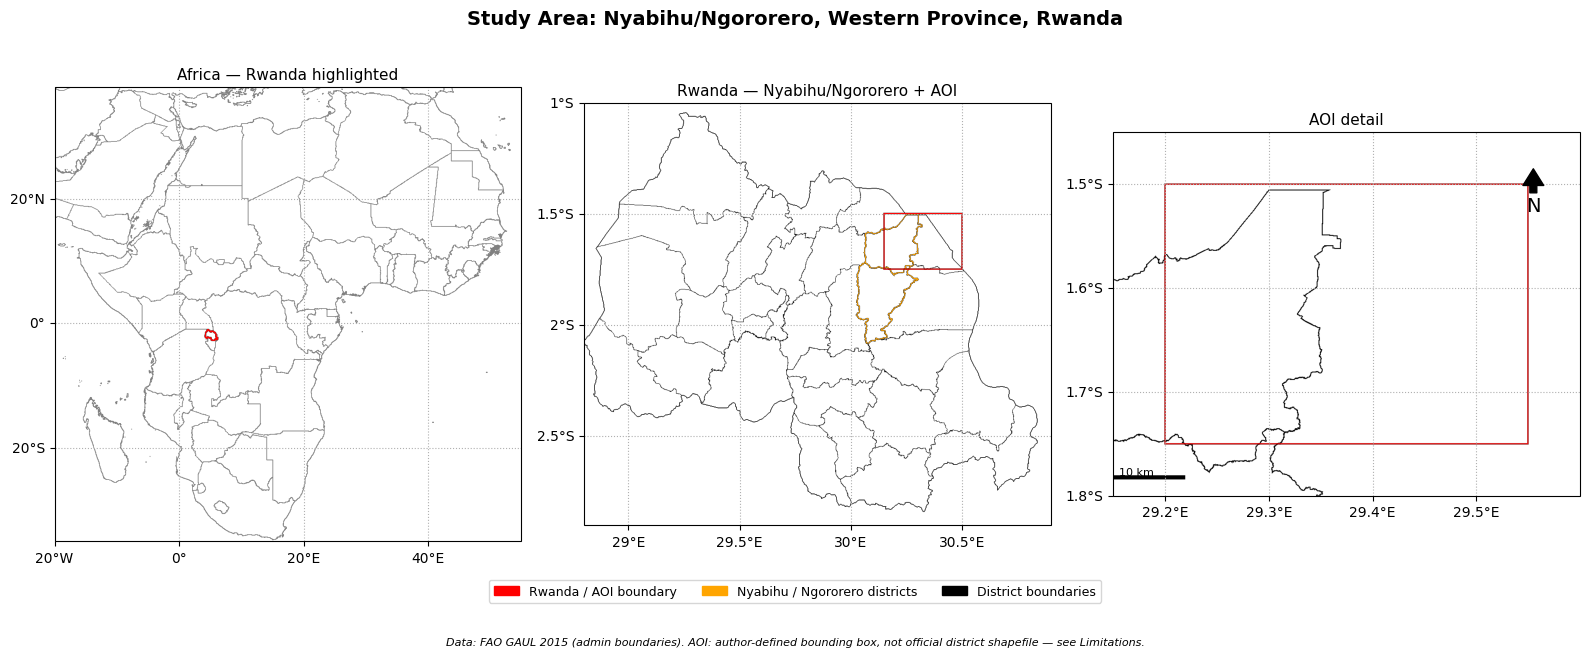

In [ ]:
import ee
import geemap
from geemap import cartoee
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs # Retained for cartopy projection
from cartopy.mpl.geoaxes import GeoAxes, GeoAxesSubplot # Retained for GeoAxes definition

ee.Authenticate() # Retained for Earth Engine authentication
ee.Initialize(project="sar-research-505215") # Retained for Earth Engine project ID

# ----------------------------------------------------------------
# 1. Define geometries
# ----------------------------------------------------------------
aoi = ee.Geometry.Rectangle([29.20, -1.75, 29.55, -1.50])

rwanda = ee.FeatureCollection('FAO/GAUL/2015/level0') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Rwanda'))

# District-level boundaries for context (Nyabihu, Ngororero)
districts = ee.FeatureCollection('FAO/GAUL/2015/level2') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Rwanda'))

target_districts = districts.filter(
    ee.Filter.inList('ADM2_NAME', ['Nyabihu', 'Ngororero'])
)

# ----------------------------------------------------------------
# 2. Build the figure with 3 panels
# ----------------------------------------------------------------
fig = plt.figure(figsize=(16, 6))

# --- Panel 1: Africa with Rwanda highlighted ---
ax1 = plt.subplot(1, 3, 1, projection=ccrs.PlateCarree()) # Updated to ccrs.PlateCarree()
africa_region = [-20, -35, 55, 38]  # rough Africa bounding box [W, S, E, N]

# Use a neutral basemap image (blended composite) as backdrop context
blank = ee.Image().paint(
    ee.FeatureCollection('FAO/GAUL/2015/level0'), 0, 1
)
cartoee.add_layer(ax1, blank, region=africa_region, vis_params={'palette': ['grey']})
cartoee.add_layer(ax1, ee.Image().paint(rwanda, 1, 3), region=africa_region,
                   vis_params={'palette': ['red']})
ax1.set_extent([africa_region[0], africa_region[2], africa_region[1], africa_region[3]],
               crs=ccrs.PlateCarree()) # Corrected to ccrs.PlateCarree()
ax1.set_title("Africa — Rwanda highlighted", fontsize=11)
cartoee.add_gridlines(ax1, interval=[20, 20], linestyle=":")

# --- Panel 2: Rwanda with Western Province / AOI box highlighted ---
ax2 = plt.subplot(1, 3, 2, projection=ccrs.PlateCarree()) # Updated to ccrs.PlateCarree()
rwanda_region = [28.8, -2.9, 30.9, -1.0]  # Rwanda bounding box

cartoee.add_layer(ax2, ee.Image().paint(rwanda, 0, 1), region=rwanda_region,
                   vis_params={'palette': ['grey']})
cartoee.add_layer(ax2, ee.Image().paint(districts, 0, 1), region=rwanda_region,
                   vis_params={'palette': ['black']})
cartoee.add_layer(ax2, ee.Image().paint(target_districts, 1, 2), region=rwanda_region,
                   vis_params={'palette': ['orange']})
# Draw the AOI box explicitly
cartoee.add_layer(ax2, ee.Image().paint(ee.FeatureCollection([ee.Feature(aoi)]), 1, 3),
                   region=rwanda_region, vis_params={'palette': ['red']})
ax2.set_extent([rwanda_region[0], rwanda_region[2], rwanda_region[1], rwanda_region[3]],
               crs=ccrs.PlateCarree()) # Corrected to ccrs.PlateCarree()
ax2.set_title("Rwanda — Nyabihu/Ngororero + AOI", fontsize=11)
cartoee.add_gridlines(ax2, interval=[0.5, 0.5], linestyle=":")

# --- Panel 3: Zoomed AOI with district boundary ---
ax3 = plt.subplot(1, 3, 3, projection=ccrs.PlateCarree()) # Updated to ccrs.PlateCarree()
aoi_region = [29.15, -1.80, 29.60, -1.45]

cartoee.add_layer(ax3, ee.Image().paint(target_districts, 0, 2), region=aoi_region,
                   vis_params={'palette': ['black']})
cartoee.add_layer(ax3, ee.Image().paint(ee.FeatureCollection([ee.Feature(aoi)]), 1, 3),
                   region=aoi_region, vis_params={'palette': ['red']})
ax3.set_extent([aoi_region[0], aoi_region[2], aoi_region[1], aoi_region[3]],
               crs=ccrs.PlateCarree()) # Corrected to ccrs.PlateCarree()
ax3.set_title("AOI detail", fontsize=11)
cartoee.add_north_arrow(ax3, text="N", xy=(0.9, 0.9), text_color="black",
                         arrow_color="black", fontsize=14)
cartoee.add_scale_bar_lite(ax3, length=10, xy=(0.05, 0.05), linewidth=3,
                            fontsize=8, color="black", unit="km")
cartoee.add_gridlines(ax3, interval=[0.1, 0.1], linestyle=":")

# ----------------------------------------------------------------
# 3. Shared legend + caption
# ----------------------------------------------------------------
legend_patches = [
    mpatches.Patch(color='red', label='Rwanda / AOI boundary'),
    mpatches.Patch(color='orange', label='Nyabihu / Ngororero districts'),
    mpatches.Patch(color='black', label='District boundaries')
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Study Area: Nyabihu/Ngororero, Western Province, Rwanda",
             fontsize=14, fontweight='bold')
fig.text(0.5, -0.08,
         "Data: FAO GAUL 2015 (admin boundaries). AOI: author-defined bounding box, "
         "not official district shapefile — see Limitations.",
         ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('study_area_locator_map.png', dpi=300, bbox_inches='tight')
plt.show()

EEException: Project 'projects/YOUR-GEE-PROJECT-ID' not found or deleted.

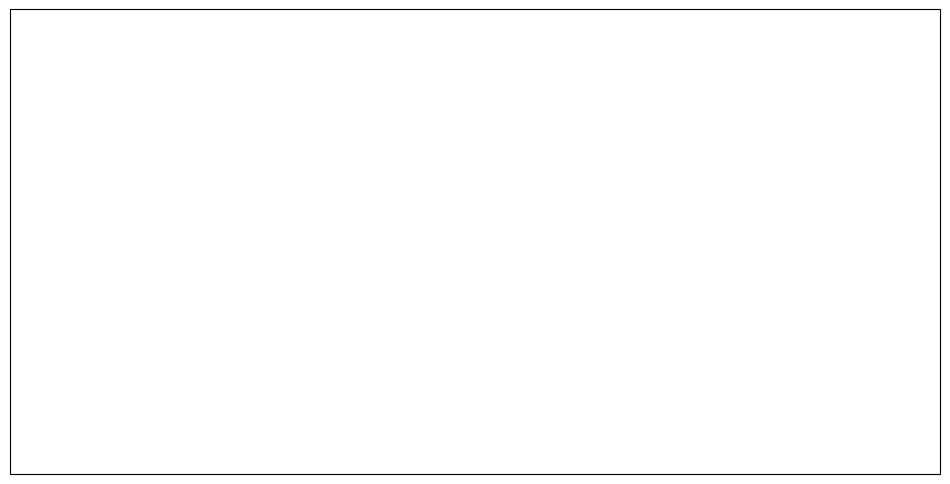

In [ ]:
# ============================================
# ATLAS-QUALITY FLOOD EXTENT MAP
# Run this in Google Colab (colab.research.google.com)
# ============================================

# STEP 1 — Install packages (run this cell first, only once per Colab session)
!pip install geemap cartopy -q

# STEP 2 — Import and authenticate to YOUR Earth Engine account
import ee
import geemap
from geemap import cartoee
import matplotlib.pyplot as plt

ee.Authenticate()  # This opens a login popup — use your GEE account
ee.Initialize(project='sar-research-505215')  # Replace with your actual GEE project ID

# ============================================
# STEP 3 — Rebuild your flood detection (same as your original script)
# ============================================

aoi = ee.Geometry.Rectangle([29.20, -1.75, 29.55, -1.50])  # Your AOI

s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(aoi) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    .select('VH')

before = s1.filterDate('2023-04-15', '2023-04-30').mean().clip(aoi)
after  = s1.filterDate('2023-05-03', '2023-05-10').mean().clip(aoi)

beforeFiltered = before.focal_mean(50, 'circle', 'meters')
afterFiltered  = after.focal_mean(50, 'circle', 'meters')

diff = afterFiltered.subtract(beforeFiltered)

flooded = diff.lt(-3).selfMask()  # Manual -3dB threshold, your primary result

# ============================================
# STEP 4 — Build the atlas-quality map with cartoee
# ============================================

fig = plt.figure(figsize=(12, 10))

# Visualization parameters — flood extent in a clear, bold color
vis_params = {'palette': ['#d73027']}  # Strong red for visibility

ax = cartoee.get_map(flooded, region=aoi.bounds().getInfo()['coordinates'],
                       vis_params=vis_params)

# Add a basemap underneath for context (satellite or terrain)
cartoee.add_layer(ax, before.visualize(min=-25, max=0, palette=['black', 'white']),
                   region=aoi.bounds().getInfo()['coordinates'])
cartoee.add_layer(ax, flooded, vis_params, region=aoi.bounds().getInfo()['coordinates'])

# Gridlines (coordinate lat/long lines)
cartoee.add_gridlines(ax, interval=[0.1, 0.1], linestyle=':')

# North arrow
cartoee.add_north_arrow(ax, text='N', xy=(0.05, 0.9),
                          text_color='black', arrow_color='black', fontsize=20)

# Scale bar
cartoee.add_scale_bar_lite(ax, length=10, xy=(0.05, 0.05), fontsize=10,
                             color='black', unit='km')

# Title
ax.set_title('Sentinel-1 SAR-Detected Flood Extent\nNyabihu-Ngororero, Rwanda — May 2023',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('flood_extent_map.png', dpi=300, bbox_inches='tight')
plt.show()

print("Map saved as flood_extent_map.png — download it from the Colab file panel on the left.")